# `kNNpy.kNN_2D_Ang` Tutorial: Clustering in the sky using 2D $k$-nearest neighbour distributions

# Part 1: Auto-clustering of discrete tracers

**Author**: Kaustubh Rajesh Gupta (email:[kaustubhrajeshgupta@swin.edu.au](mailto:kaustubhrajeshgupta@swin.edu.au))
\
**Date**: 12 july 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_2D_Ang` module to compute the 2D $k$NN-CDFs in angular coordinates for given data and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological data. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_2D_Ang.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
## Contents:

- [Imports and setup](#Imports-and-setup)
- [Load mock galaxy data](#mock)
- [Vizualize the data](#Let's-vizualize-how-tracers-are-distributed-in-the-sky)
- [Compute the relevant spatial scales](#The-first-step-is-to-compute-the-relevant-spatial-scales-of-interest-at-which-the-$k$NN-distributions-can-be-computed.)
- [Construct the query points](#que)
- [Compute the $k$NN-CDFs](#cdf)
- [Plot the results](#let's-plot-the-results,-comparing-the-evaluated-CDFs-against-the-theoretical-expectation-for-unclustered-data:)
- [Interpretation of the CDFs](#Interpretation)
- [Thinking challenge](#Thinking-challenge)
- [Quantifying the clustering signal](#Quantifying-the-clustering-signal)
- [Computational Challenge](#Computational-Challenge)

## Imports and setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [2]:
#Importing external libraries

import numpy as np

import healpy as hp
from healpy.newvisufunc import projview

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import HelperFunctions_2DA as hf_2DA         #2D specifi helper functions
from kNNpy import kNN_2D_Ang                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [3]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

## Main

#### <a name="mock" id="mock"></a> We will illustrate how to use `kNNpy` using a sample of galaxy-scale dark matter haloes from the publicly available [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/). This dataset was created by projecting the 3D positions of the haloes onto the sky of a hypothetical observer at the centre of the simulation box.

In [4]:
#Defining the galaxy sample

NSIDE = 256                 #determines the HEALpix angular resolution for the calculations
n_reals = 1                 #the number of tracer sets (realisations) sampled from the box; let's start with a single realisation
n_tracer = 20_000           #the number of discrete tracers
sim_num = 0                 #the quijote box number used. Currently, only simulation box 0 comes pre-loaded with kNNpy
mask = np.ones(12*NSIDE**2) #the observational footprint; for this example, let's set it to the entire sky
mask[mask!=1] = hp.UNSEEN

In [5]:
#Creating the galaxy catalogue from the quijote box using the kNNpy.Data.Datasets module

#If you want reproducible results, you can fix the seed used to generate the random sample by providing a value to the seed parameter
ga_pos_arr, ga_map = Datasets.Sample2DTracersFromQuijoteBox(sim_num=sim_num, tracer_type='Galaxies', mask=mask, N_realisations=1, n_tracers=n_tracer, seed=None, map_NSIDE=64, DataPath='../kNNpy/Data')
ga_pos = ga_pos_arr[0]      #'ga_pos' contains the positions of the galaxies in the sky

#### Let's vizualize how tracers are distributed in the sky

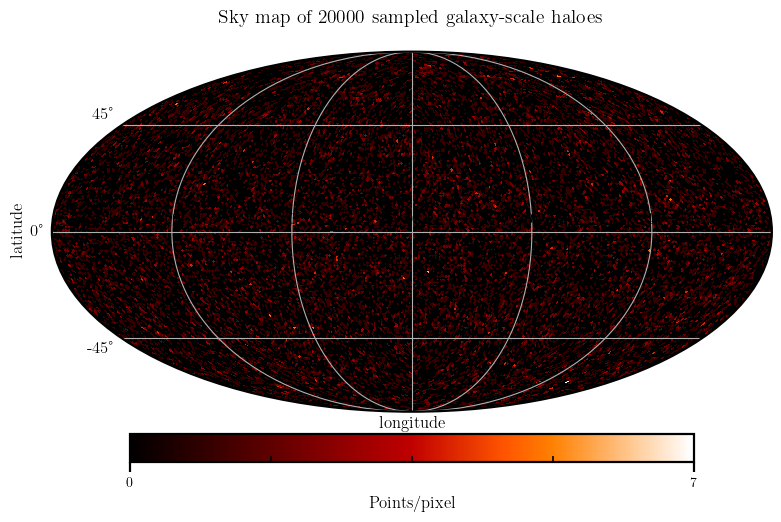

In [6]:
plt.rcParams.update({'font.size': 40})

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(1, 1, 1)

plt.axes(ax1)
projview(
    ga_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"Sky map of {n_tracer} sampled galaxy-scale haloes\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    hold=True,
    sub=111,
)

plt.show()
plt.close()

plt.rcParams.update({'font.size': 18})

The clustered nature of the haloes can clearly be seen the sky map, and it is our task to quantify the extent of this clustering. 

#### The first step is to compute the relevant spatial scales of interest at which the $k$NN distributions can be computed.

Remember, the $k$NN statistcs are the cumulative distribution functions of the tracers' nearest-neighbour distances from random points on the sky. The more densely populated the sky is, the smaller are these neighbnouring distances, and the smaller is the angular scale probed by the $k$NN distributions. A general rule of thumb is to use the spatial scales at which the $k$NN-CDFs are expected to be between 0.05 and 0.95 to avoid the saturated tails of the distribution.

#### To estimate the relevant spatial scales, we can use the expected $k$NN-CDFs for unclustered tracers with given number density, which can be defined analytically. Let's do that for the first, second and fourth nearst neighbours using the in-build `PoissonUniformCDFs()` helper function:

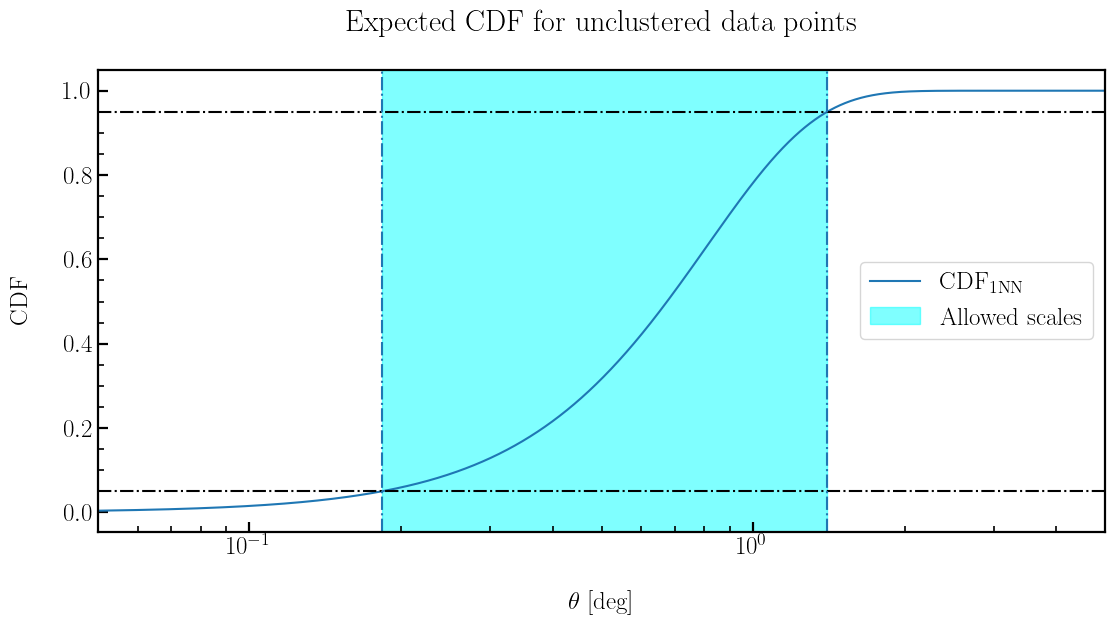

Relevant angular distance scales (deg):

	1NN:	 0.18 1.40
	2NN:	 0.48 1.77
	4NN:	 0.95 2.26


In [10]:
#Defining which neighbours to use
k_List = [1, 2, 4]

#Getting the tracer number density
n_bar_red = (ga_pos.shape[0]/(4*np.pi))*(12*NSIDE**2/len(np.where(mask!=hp.UNSEEN)[0]))

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.deg2rad(np.geomspace(0.05, 10, 10000))

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(bins[i])), n_bar_red, k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

sel_bins = np.zeros((len(k_List), 10))
for i, k in enumerate(k_List):
    sel_bins[i] = np.geomspace(bins[i][low_bin[i]]*0.95, bins[i][high_bin[i]]*1.05, 10)

th_uni_arr = np.zeros((len(k_List), sel_bins.shape[1]))
for i, k in enumerate(k_List):
    th_uni_arr[i] = hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(sel_bins[i])), n_bar_red, k)

#Let's plot the expected 1NN-CDF for the unclustered data
plt.figure(figsize=(13,6))
i=0    #change the value of i and k to plot a different kNN-CDF
k=1
plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(np.rad2deg(bins[i][low_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvline(np.rad2deg(bins[i][high_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvspan(np.rad2deg(bins[i][low_bin[i]]), np.rad2deg(bins[i][high_bin[i]]), alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([0.05, 5])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(np.rad2deg(bins[i][low_bin[i]])), '{:.2f}'.format(np.rad2deg(bins[i][high_bin[i]])))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

#### <a name="que" id="que"></a> The next step is to construct the query points from which the nearest-neighbour distances are to be computed. 

The query points can be on a pixel grid or randomly distributed in the sky, and need to sample the sky densely, such that the number of query points is always much greater than the number of data points. Currently, `kNNpy.kNN_2D_Ang` only supports query points on a HEALPix grid, with the number of query points equal to ``12*NSIDE**2``.

In [11]:
#Generate the query positions
query_mask, query_pos = hf_2DA.create_query_2DA(NSIDE, mask)

#### <a name="cdf" id="cdf"></a> Now, we are ready to compute the $k$NN-CDFs and measure the angular auto-clustering of the Quijote galaxy-scale dark matter haloes! Let's do that using the `TracerAuto2DA()` method:

In [12]:
#Print the API documentation for details on the function usage
help(kNN_2D_Ang.TracerAuto2DA)

Help on function TracerAuto2DA in module kNNpy.kNN_2D_Ang:

TracerAuto2DA(kList, BinsRad, MaskedQueryPosRad, MaskedTracerPosRad, ReturnNNdist=False, Verbose=False)
    Computes the $k$NN-CDFs in 2D angular coordinates (Banerjee & Abel (2021)[^1], Gupta & Banerjee (2024)[^2]) of the provided discrete tracer set (`MaskedTracerPosRad`), evaluated at the provided angular distance scales `BinsRad`, for all $k$ in `kList`. Each $k$NN-CDF measures the probability $P_{\geq k}(\theta)$ of finding at least $k$ tracers in a randomly placed spherical cap of radius $\theta$. The $k$NN-CDFs quantify the spatial clustering of the tracers.

    Parameters
    ----------
    kList : int
        the list of nearest neighbours to calculate the distances to. For example, if ``kList = [1, 2, 4]``, the first, second and fourth-nearest neighbour distributions will be computed.
    BinsRad : list of numpy float array
        list of angular distance arrays (in radians) for each nearest neighbour. The $i^{th}$

In [13]:
#compute the CDFs. Set Verbose=False to not print diagnostic information
ga_kNN_results = kNN_2D_Ang.TracerAuto2DA(k_List, sel_bins, query_pos, ga_pos, ReturnNNdist=False, Verbose=True)

Checking inputs ...
	done.

building the tree ...
	done; time taken: 1.28e-02 s.

computing the tracer NN distances ...
	done; time taken: 3.74e+00 s.

computing the tracer auto-CDFs P_{>=k} ...
	done; time taken: 1.62e-01 s.

total time taken: 3.92e+00 s.


#### let's plot the results, comparing the evaluated CDFs against the theoretical expectation for unclustered data:

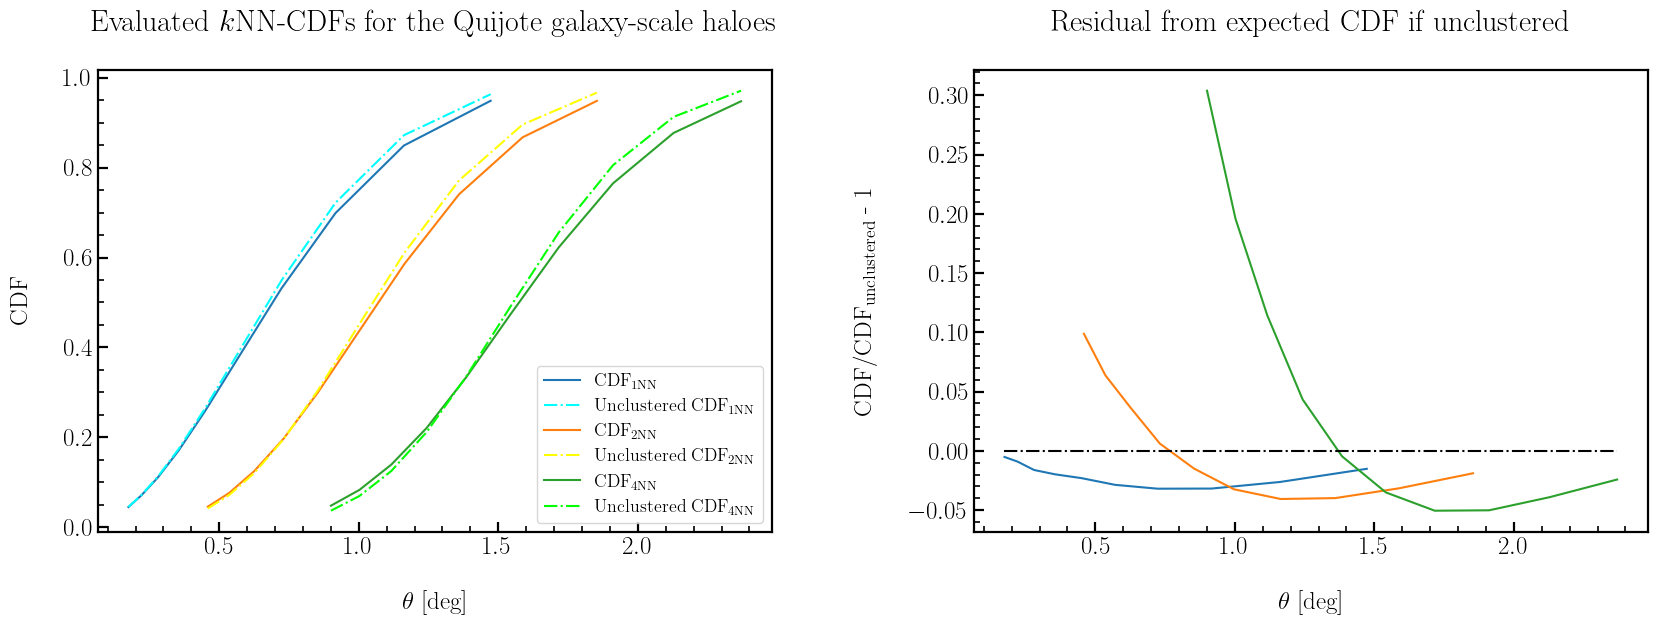

In [14]:
fig, (ax, ax1) = plt.subplots(1, 2, figsize=(20,6))

for i, k in enumerate(k_List):
    ax.plot(np.rad2deg(sel_bins[i]), ga_kNN_results[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
    ax.plot(np.rad2deg(sel_bins[i]), th_uni_arr[i], label='Unclustered CDF$_{{\\rm {}NN}}$'.format(k), c=BrightColors[i], ls='-.')
    ax1.plot(np.rad2deg(sel_bins[i]), ga_kNN_results[i]/th_uni_arr[i]-1, label=None, c=DefaultColorCycle[i])
    ax.set_xlabel('\n$\\theta$ [deg]')
    ax1.set_xlabel('\n$\\theta$ [deg]')
    ax.set_ylabel('CDF\n')
    ax1.set_ylabel('CDF/CDF$_{\\rm unclustered}$ - 1\n')
ax.legend(fontsize=13)
ax1.plot(np.rad2deg(np.linspace(sel_bins[0][0], sel_bins[-1][-1], 100)), np.zeros(100), label=None, c='k', ls='-.')
ax.set_title('Evaluated $k$NN-CDFs for the Quijote galaxy-scale haloes\n')
ax1.set_title('Residual from expected CDF if unclustered \n')
plt.subplots_adjust(wspace=0.3)
plt.show()
plt.close()

#### Interpretation

As indicated in the plots presented above, the CDF$_{\rm 1NN}$ for our dataset is lower than the expected CDF$_{\rm 1NN}$ for an unclustered dataset at all distance scales. This tells us that tells us that the mock galaxies we are looking at are not distributed randomly in the sky, but are clustered, since on average, the probability of finding a galaxy within an angular distance $\theta$ of a randomly chosen point on the sky is always lower than that of finding another randomly-distributed data point the same distance away. 

Another way of thinking about this result is as follows: the distance between a randomly-picked point in the sky and an object belonging to a spatially-clustered data set is, on average, larger than the distance between a randomly-picked point and an object belonging to a spatially-unclustered data set. This is because the voids in the spatial distribution of clustered objects that are larger than voids in the spatial distribution of randomly-distributed objects.

#### Thinking challenge

You might have noticed that while the CDF$_{\rm 1NN}$ of the clustered data is always lower than that expected from unclustered data at all distance scales, the same is not true for the CDF$_{\rm 2NN}$ and CDF$_{\rm 4NN}$; these transition from being higher than the unclustered value at smaller distances to lower at higher distances, with the distance scale at which the transition happens being larger for 4NN than 2NN. In fact, this is true for all CDF$_{k \rm NN}$ for $k>1$. How can we explain this? 

#### Quantifying the clustering signal

Okay, so far we have seen how the $k$NN-CDFs of clustered data are different than those of randomly-distributed or unclustered data. But how can we use the measured CDFs to say for certain whether our data sets are clustered or not, and once we have measured the CDFs, how do we quantify the extent of the clustering?

To answer the questions raised above, we need to quantify the noise in our measurements. One method to quantify the noise is to measure the variance in the CDFs across many independent realisations of unclustered (Poisson distributed) data in the sky, or 'randoms' for short. Only if the difference between the CDF of the clustered data and the CDF expected from unclustered data is significantly larger than the standard deviation across the randoms, we can conclude that the data is clustered.

#### Let's create 10 realisations of Poission-distributed data using the in-build `Datasets.Sample2DPoissonTracer()` function, and visualize them
Remember, the $k$NN-CDFs are sensitive to sky number density, so we need to make sure the randoms have the same number of data points in each realisation as the number of mock galaxies. Ideally, the number of realisations should be much larger, but for this tutorial, let's work with 10 realisations to save time. 

In [15]:
#Set the number of random realisations. Ideally, this should be a large number (>100), but for this tutorial, let's work with 10 realisations to save time.
n_reals = 10

#Creating 10 of realisations of randoms on the sky to estimate the noise. If you want reproducible results, you can fix the seed used to generate the random sample by providing a value to the seed parameter
randoms_pos_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

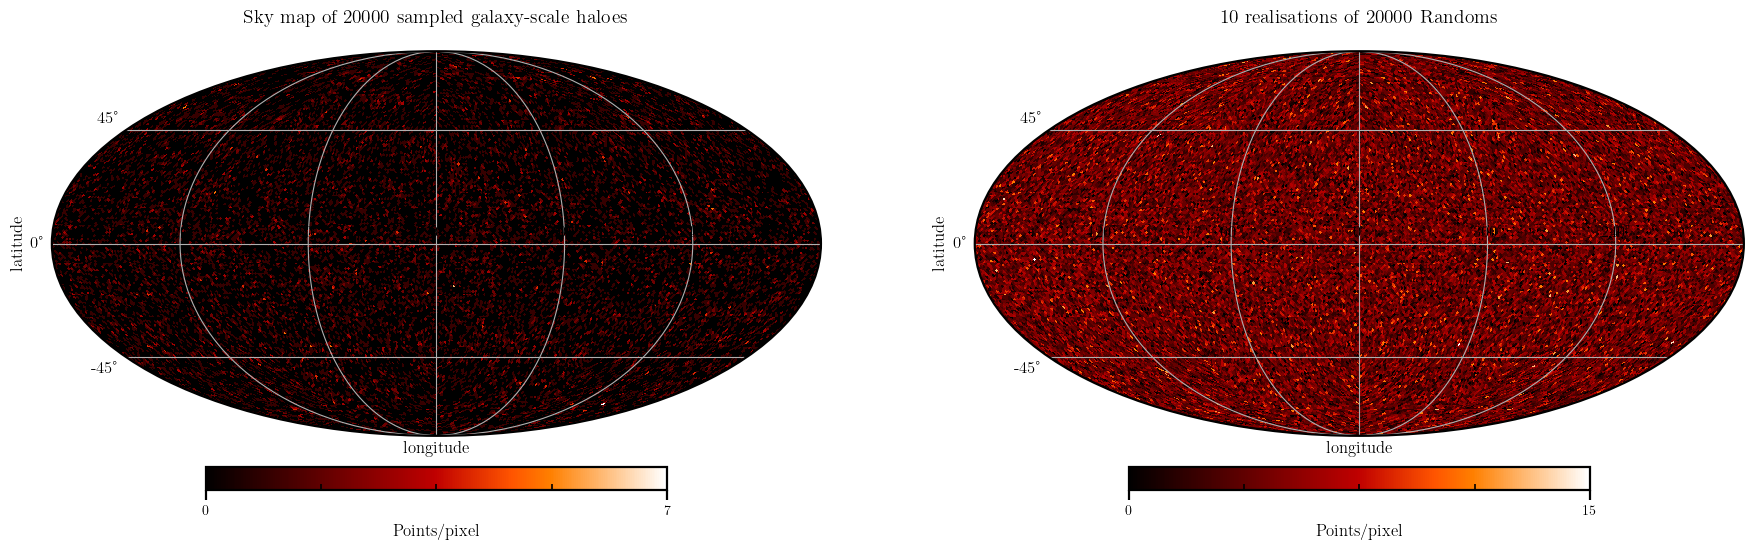

In [19]:
fig = plt.figure(figsize=(18, 7))
ax1, ax3 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    ga_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"Sky map of {n_tracer} sampled galaxy-scale haloes\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    hold=True,
    sub=121,
)

plt.axes(ax3)
projview(
    randoms_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} Randoms\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    # min=map_1[mask!=hp.UNSEEN].min(),
    # max=map_1[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=122
)

plt.show()
plt.close()

We can see that the randoms are visually more evenly distributed on the sky and less clustered than the galaxies.

#### Let's compute the CDFs for the randoms and compare them to the expected analytical value for unclustered data, as well as the CDFs we computed for the galaxies:

In [21]:
randoms_kNN_results_list = []

#Looping over the realisations
for realisation in range(n_reals):
    print(f'\n\n############################################################################   Computing for realisation {realisation+1}/{n_reals}   ############################################################################\n\n')
    randoms_kNN_results_list.append(kNN_2D_Ang.TracerAuto2DA(k_List, sel_bins, query_pos, randoms_pos_arr[realisation], ReturnNNdist=False, Verbose=True))

    



############################################################################   Computing for realisation 1/10   ############################################################################


Checking inputs ...
	done.

building the tree ...
	done; time taken: 1.19e-02 s.

computing the tracer NN distances ...
	done; time taken: 3.71e+00 s.

computing the tracer auto-CDFs P_{>=k} ...
	done; time taken: 1.60e-01 s.

total time taken: 3.89e+00 s.


############################################################################   Computing for realisation 2/10   ############################################################################


Checking inputs ...
	done.

building the tree ...
	done; time taken: 3.62e-03 s.

computing the tracer NN distances ...
	done; time taken: 3.80e+00 s.

computing the tracer auto-CDFs P_{>=k} ...
	done; time taken: 1.57e-01 s.

total time taken: 3.96e+00 s.


############################################################################   Computing for reali

In [23]:
randoms_kNN_results = np.array(randoms_kNN_results_list)
mean_randoms_kNN_autoCDFs = np.mean(randoms_kNN_results, axis=0)

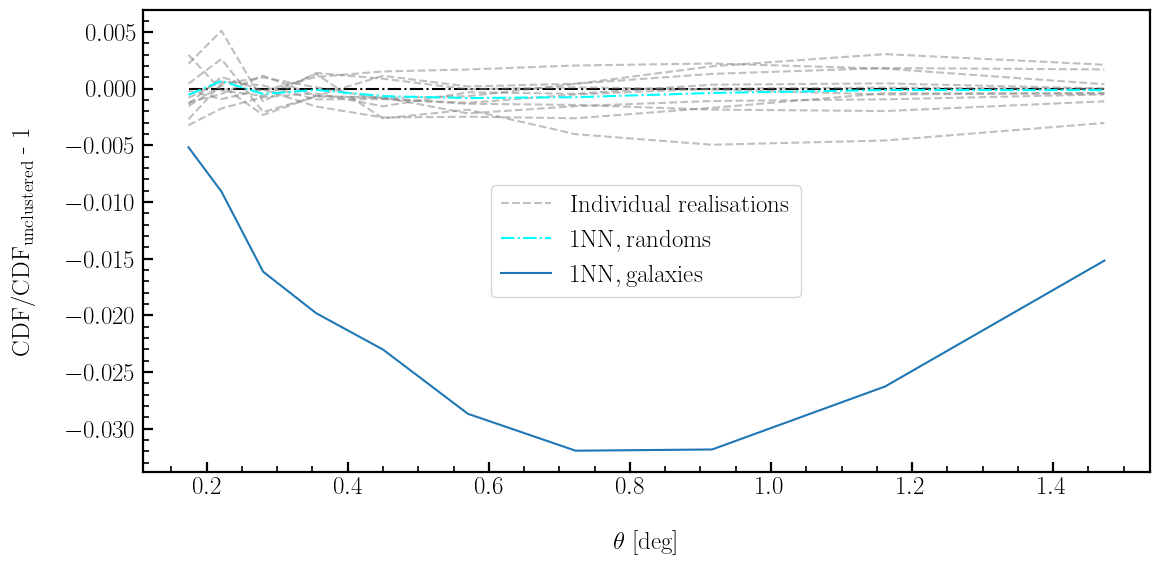

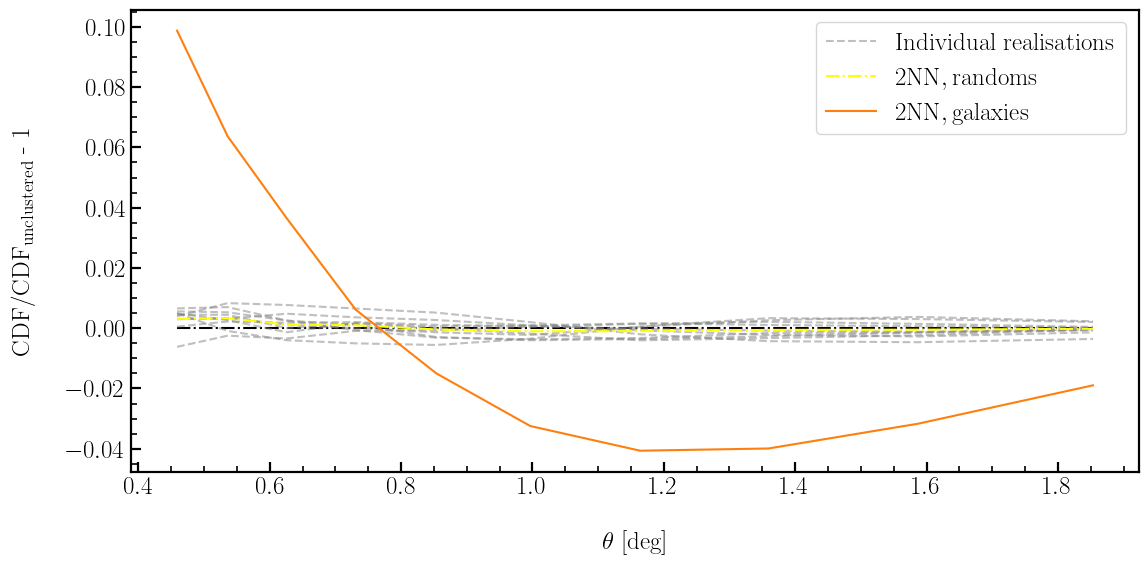

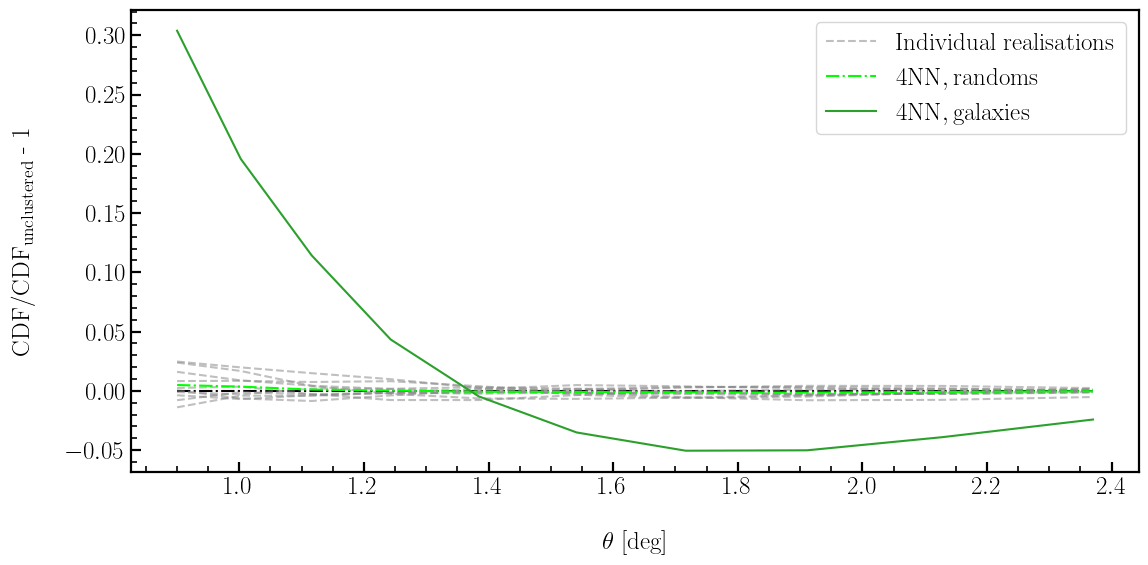

In [51]:
for i, k in enumerate(k_List):
    plt.figure(figsize=(13, 6))
    label = 'Individual realisations'
    plt.plot(np.rad2deg(sel_bins[i]), (th_uni_arr[i]/th_uni_arr[i] - 1), 'k-.', label=None)
    random_autoCDFs = randoms_kNN_results[0]
    plt.plot(np.rad2deg(sel_bins[i]), (random_autoCDFs[i]/th_uni_arr[i] - 1), ls='--', c='grey', alpha=0.5, label=label)
    for realisation in range(n_reals)[1:]:
        random_autoCDFs = randoms_kNN_results[realisation]
        plt.plot(np.rad2deg(sel_bins[i]), (random_autoCDFs[i]/th_uni_arr[i] - 1), ls='--', c='grey', alpha=0.5, label=None)
    plt.plot(np.rad2deg(sel_bins[i]), (mean_randoms_kNN_autoCDFs[i]/th_uni_arr[i] - 1), ls='-.', c=BrightColors[i], label='${{\\rm {}NN}}, {{\\rm randoms}}$'.format(k))
    plt.plot(np.rad2deg(sel_bins[i]), (ga_kNN_results[i]/th_uni_arr[i] - 1), ls='-', c=DefaultColorCycle[i], label='${{\\rm {}NN}}, {{\\rm galaxies}}$'.format(k))
    plt.xlabel('\n$\\theta$ [deg]')
    plt.ylabel('CDF/CDF$_{\\rm unclustered}$ - 1\n')
    plt.legend()
    plt.show()
    plt.close()

#### We see that the CDFs for the randoms agree to the analytical expectation for unclustered data to within $\sim2$% or so. Moreover, the differnce between the mock galaxy CDFs and the randoms CDFs are much larger than the scatter across the randoms realisaitons, confirming that we have a strong detection of clustering! 

#### Computational Challenge

Using the measurements performed above, can you compute the statistical significance of the clustering detection?

**Hint:** think of this as testing a Null hypothesis. What is the null hypothesis? What quantity can you compute to test the null hypothesis?

**Caution:** the $k$NN-CDFs are highly correlated across the distance bins, so you need to take these cross-bin correlations into account while computing the statistical significance of the detection

In [45]:
#Type your solution below